## Instructions

Your objective is to delve into the World Happiness Report dataset, which includes columns like `Country`, `Year`, `Happiness_Score`, `GDP_per_Capita`, `Social_Support`, `Healthy_Life_Expectancy`, `Freedom_to_Make_Life_Choices`, `Generosity`, and `Perceptions_of_Corruption`.

1. **Load and Inspect Data**:
    - Utilize pandas to load the World Happiness Report Dataset.
    - Examine the data to grasp its structure and contents of the year 2019.

2. **Data Preprocessing**:
    - Address missing values and adjust data types as necessary.

3. **Social Support and Happiness**:
    - Employ a Matplotlib scatter plot to investigate the relationship between ‘Social support’ and ‘Score’.

4. **Regional Comparisons of GDP and Health**:

    - Create a Matplotlib subplot that compares ‘GDP per Capita’ and ‘Healthy Life Expectancy’ across different regions.
    - Use a bar plot for ‘GDP per Capita’ and a line plot for ‘Healthy Life Expectancy’ on the same axes to observe how economic strength relates to health outcomes in different regions.

### Answer

In [125]:
# 1. Load and Inspect Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('data/2019.csv')

df.head(10)


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


In [126]:
df.shape

(156, 9)

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    str    
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 11.1 KB


In [128]:
df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


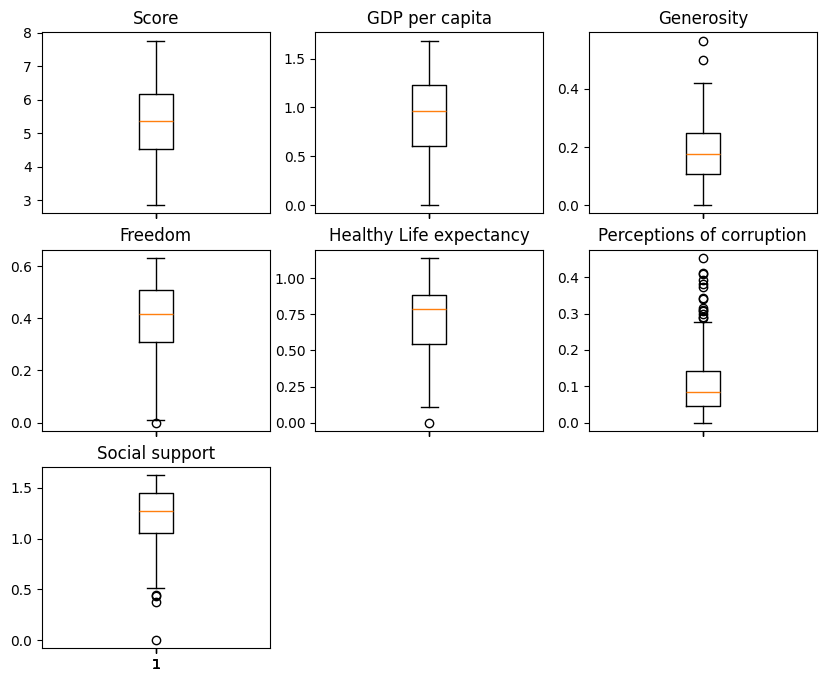

In [129]:
# Data preprocessing

# Check distribution of each variable using boxplots
fig, axs = plt.subplots(3,3, figsize=(10, 8), sharex=True)

axs[0,0].boxplot(df['Score'])
axs[0,0].set_title('Score')

axs[0,1].boxplot(df['GDP per capita'])
axs[0,1].set_title('GDP per capita')

axs[0,2].boxplot(df['Generosity'])
axs[0,2].set_title('Generosity')

axs[1,0].boxplot(df['Freedom to make life choices'])
axs[1,0].set_title('Freedom')

axs[1,1].boxplot(df['Healthy life expectancy'])
axs[1,1].set_title('Healthy Life expectancy')

axs[1,2].boxplot(df['Perceptions of corruption'])
axs[1,2].set_title('Perceptions of corruption')

axs[2,0].boxplot(df['Social support'])
axs[2,0].set_title('Social support')

fig.delaxes(axs[2,1])
fig.delaxes(axs[2,2])

In [130]:
# Cap outliers for 'Perceptions of corruption' at 95th percentile
corruption_cap = df['Perceptions of corruption'].quantile(0.95)

outliers_count = (df['Perceptions of corruption'] > corruption_cap).sum()

print(f"Capping corruption index at 95th percentile: {corruption_cap}")
print(f"Values to be capped: {outliers_count}")
print("Before capping")
print(f"Max corruption index: {df['Perceptions of corruption'].max()}")


df['Perceptions of corruption'] = df['Perceptions of corruption'].clip(upper=corruption_cap)
# Show before/after max values
print("After capping")
print(f"Max corruption index: {df['Perceptions of corruption'].max()}")

Capping corruption index at 95th percentile: 0.32225000000000004
Values to be capped: 8
Before capping
Max corruption index: 0.453
After capping
Max corruption index: 0.32225000000000004


#### Data Processing

The dataset was inspected for missing values and data type inconsistencies.
No missing values were found in any of the columns.
All numerical variables were already stored using appropriate numeric data types (int64 and float64), and the categorical variable (“Country or region”) was stored as an object.
The only issue were the outliers, which were very noticeable at the 'Perceptions of corruption' variable. Therefore, we opted for capping the corresponding data points at the 95th percentile.

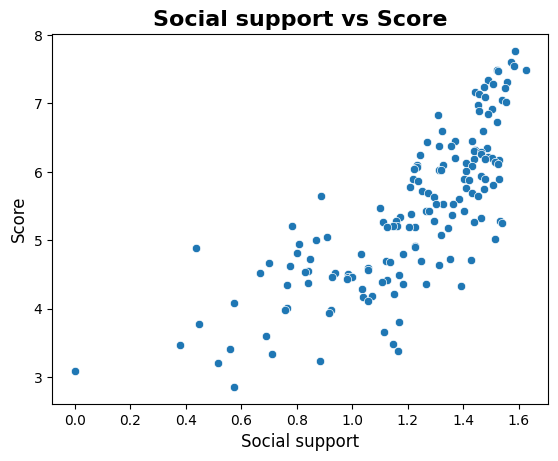

In [131]:
# Create scatterplot to investigate relationship between Social support and Score
fig, ax = plt.subplots()

ax = sns.scatterplot(data=df, x='Social support', y='Score')
ax.set_title("Social support vs Score", fontsize=16, fontweight='bold')
ax.set_xlabel("Social support", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
plt.show()

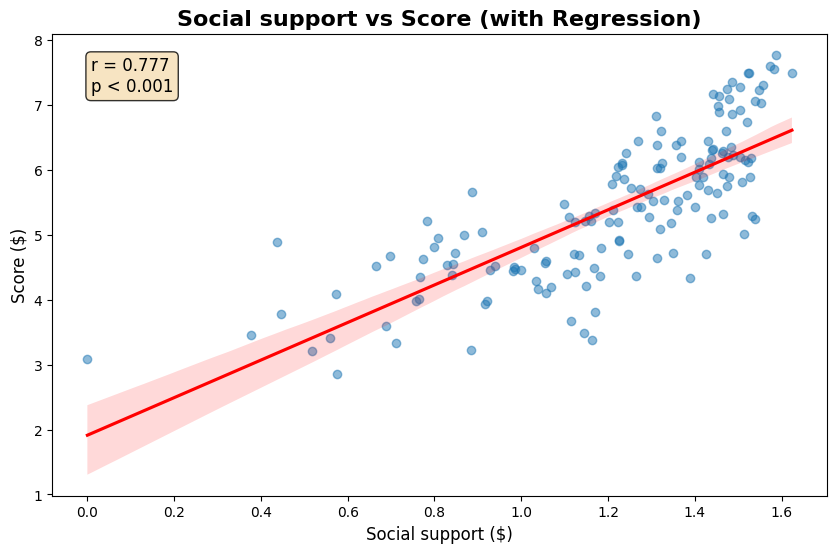

Correlation: r = 0.777 (strong positive)
P-value: 8.98e-33 (highly significant - not due to chance)


In [132]:
# Regression plot with trend line and statistics
fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.regplot(data=df, x='Social support', y='Score',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})

# Calculate and display correlation
r, p = stats.pearsonr(df['Social support'], df['Score'])
ax.text(0.05, 0.95, f'r = {r:.3f}\np < 0.001',
         transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_title('Social support vs Score (with Regression)', fontsize=16, fontweight='bold')
ax.set_xlabel('Social support ($)', fontsize=12)
ax.set_ylabel('Score ($)', fontsize=12)
plt.show()

print(f"Correlation: r = {r:.3f} (strong positive)")
print(f"P-value: {p:.2e} (highly significant - not due to chance)")

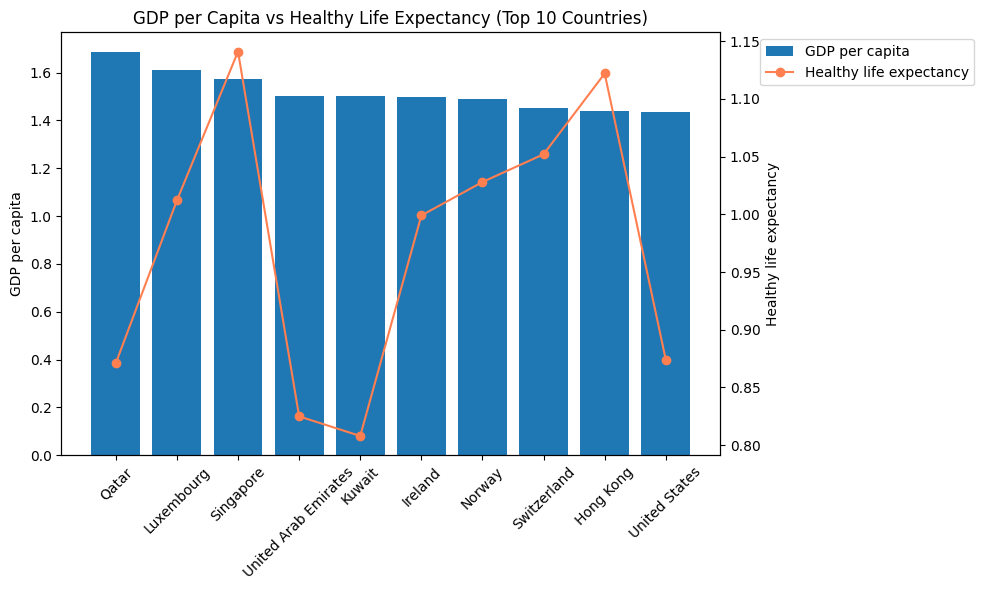

In [138]:
top = df.sort_values("GDP per capita", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,6))

# Bar plot — GDP
bars = ax.bar(
    top["Country or region"],
    top["GDP per capita"],
    label="GDP per capita"
)
ax.set_ylabel("GDP per capita")

# Line plot — Health (second axis)
ax2 = ax.twinx()
line, = ax2.plot(
    top["Country or region"],
    top["Healthy life expectancy"],
    marker="o",
    color='coral',
    label="Healthy life expectancy"
)

ax2.set_ylabel("Healthy life expectancy")

ax.tick_params(axis='x', rotation=45)
ax.set_title("GDP per Capita vs Healthy Life Expectancy (Top 10 Countries)")

# ✅ Combine legends from both axes
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

The dataset column labeled “Country or region” contains country names rather than aggregated world regions. Therefore, the comparison was performed across countries (top 10 by GDP per capita) to produce a readable visualization.